In [1]:
# Part 2 — Preprocessing:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline

df = pd.read_csv("data/housing_clean.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
top_two_skewed = ["population", "total_rooms"]

for col in top_two_skewed:
    col_mean = df[col].mean()
    col_median = df[col].median()
    print(f"{col}: mean = {col_mean:,.2f}  |  median = {col_median:,.2f}")

population: mean = 1,425.48  |  median = 1,166.00
total_rooms: mean = 2,635.76  |  median = 2,127.00


Both columns are positively skewed.
- Median is the better summary for skewed data because it is less affected by extreme values.

In [3]:
print("Before imputation:")
print(df["total_bedrooms"].isna().sum())

df["total_bedrooms"] = df.groupby("ocean_proximity")["total_bedrooms"].transform(lambda s: s.fillna(s.median()))

print("\nAfter imputation:")
print(df["total_bedrooms"].isna().sum())

Before imputation:
207

After imputation:
0


In [4]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

if n_dupes > 0:
    df = df.drop_duplicates()
    print(f"Dropped. New shape: {df.shape}")

Duplicate rows found: 0


In [5]:
print("Memory usage BEFORE dtype correction (bytes):")
mem_before = df.memory_usage(deep=True).sum()
print(f"{mem_before:,}")

Memory usage BEFORE dtype correction (bytes):
1,817,792


In [6]:
count_cols = ["total_rooms", "total_bedrooms", "population", "households"]
df[count_cols] = df[count_cols].replace([np.inf, -np.inf], np.nan)

for col in count_cols:
    df[col] = df[col].fillna(df[col].median())

df[count_cols] = df[count_cols].round().astype("int64")
df["ocean_proximity"] = df["ocean_proximity"].astype("category")

print(df.dtypes)

longitude              float64
latitude               float64
housing_median_age     float64
total_rooms              int64
total_bedrooms           int64
population               int64
households               int64
median_income          float64
median_house_value     float64
ocean_proximity       category
dtype: object


In [7]:
print("Memory usage AFTER dtype correction (bytes):")
mem_after = df.memory_usage(deep=True).sum()
print(f"{mem_after:,}")
print(f"\nMemory saved: {mem_before - mem_after:,} bytes")

Memory usage AFTER dtype correction (bytes):
1,506,932

Memory saved: 310,860 bytes


Count columns are now stored as integers.

`ocean_proximity` is converted to category for memory efficiency.

In [8]:
# Flagging Top-Coded Rows
df["is_value_capped"] = (df["median_house_value"] == df["median_house_value"].max()).astype(int)

print("Capped rows:", df["is_value_capped"].sum())

Capped rows: 965


965 rows (4.7%) have `median_house_value == $500,001` — the census reporting ceiling. We **keep** these rows but add a
binary flag so models can account for this artifact (per the outlier decision in `eda.ipynb`).

In [9]:
# Engineering Feature ratios

df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

display(df[["rooms_per_household", "bedrooms_per_room", "population_per_household"]].describe().round(2))

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.00,20640.00,20640.00
mean,5.43,0.21,3.07
std,2.47,0.07,10.39
min,0.85,0.04,0.69
25%,4.44,0.18,2.43
50%,5.23,0.20,2.82
75%,6.05,0.24,3.28
max,141.91,2.75,1243.33


These ratios reduce the effect of raw block-group size.

They also help reduce multicollinearity in the original count features.

In [10]:
# Creating income_category

df["income_category"] = pd.cut(
    df["median_income"],
    bins=[0, 2.5, 4.5, 6.0, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

print("income_category distribution:")
print(df["income_category"].value_counts().sort_index())

income_category distribution:
income_category
Low          4805
Medium       9834
High         3639
Very High    2362
Name: count, dtype: int64


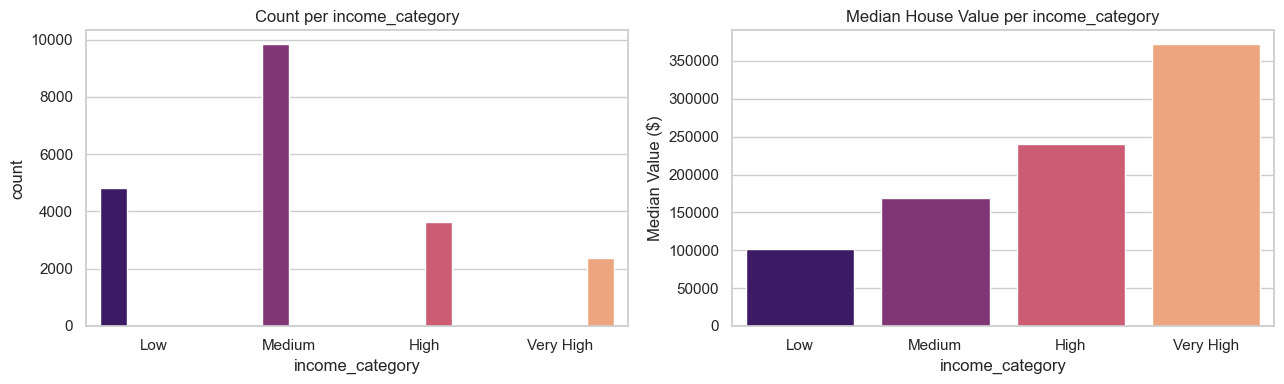

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

order = ["Low", "Medium", "High", "Very High"]

sns.countplot(
    x="income_category",
    hue="income_category",
    data=df,
    order=order,
    palette="magma",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Count per income_category")

med_val = df.groupby("income_category", observed=True)["median_house_value"].median().reindex(order)
sns.barplot(
    x=med_val.index,
    y=med_val.values,
    hue=med_val.index,
    palette="magma",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Median House Value per income_category")
axes[1].set_ylabel("Median Value ($)")

plt.tight_layout()
plt.show()

`income_category` becomes the second categorical column.

It gives the model a simple income tier feature that is easy to interpret.

In [12]:
median_val = df["median_house_value"].median()
df["expensive"] = (df["median_house_value"] > median_val).astype(int)

balance = df["expensive"].value_counts(normalize=True).round(3)
print(f"Threshold: ${median_val:,.0f}")
print(f"Class balance:\n{balance.to_string()}")

Threshold: $179,700
Class balance:
expensive
0    0.5
1    0.5


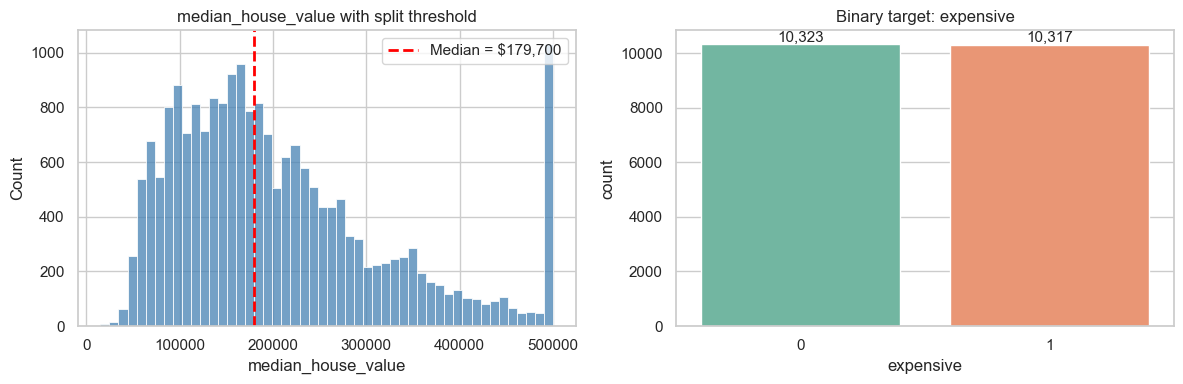

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["median_house_value"], bins=50, ax=axes[0], color="steelblue")
axes[0].axvline(median_val, color="red", linestyle="--", linewidth=2, label=f"Median = ${median_val:,.0f}")
axes[0].set_title("median_house_value with split threshold")
axes[0].legend()

sns.countplot(x="expensive", hue="expensive", data=df, palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Binary target: expensive")
axes[1].set_xlabel("expensive")

for p in axes[1].patches:
    axes[1].annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.show()

`expensive` is the binary classification target.

1 means the house is above the median house value.

In [14]:
# Before and After -- Column Summary

raw_cols = pd.read_csv("data/housing_clean.csv").columns.tolist()
new_cols = [c for c in df.columns if c not in raw_cols]

print(f"Original columns ({len(raw_cols)}): {raw_cols}")
print(f"\nAdded columns ({len(new_cols)}): {new_cols}")
print(f"\nFinal shape: {df.shape}")

Original columns (10): ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Added columns (6): ['is_value_capped', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'income_category', 'expensive']

Final shape: (20640, 16)


In [15]:
df.dtypes

longitude                    float64
latitude                     float64
housing_median_age           float64
total_rooms                    int64
total_bedrooms                 int64
population                     int64
households                     int64
median_income                float64
median_house_value           float64
ocean_proximity             category
is_value_capped                int64
rooms_per_household          float64
bedrooms_per_room            float64
population_per_household     float64
income_category             category
expensive                      int64
dtype: object

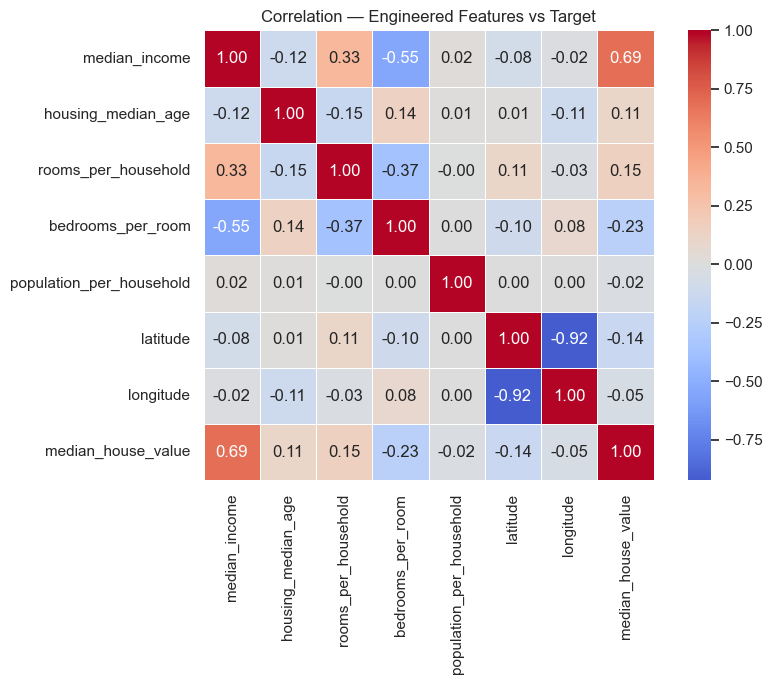

In [16]:
# Correlation Check
eng_features = [
    "median_income", "housing_median_age", "rooms_per_household",
    "bedrooms_per_room", "population_per_household",
    "latitude", "longitude", "median_house_value"
]

corr = df[eng_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, square=True)
plt.title("Correlation — Engineered Features vs Target")
plt.tight_layout()
plt.show()

In [17]:
print("\nCorrelation with median_house_value (sorted):")
print(corr["median_house_value"].drop("median_house_value").sort_values(ascending=False))


Correlation with median_house_value (sorted):
median_income               0.688075
rooms_per_household         0.151948
housing_median_age          0.105623
population_per_household   -0.023737
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.233515
Name: median_house_value, dtype: float64


In [18]:
df.to_csv("data/cleaned_data.csv", index=False)
print("Saved -> cleaned_data.csv")

Saved -> cleaned_data.csv


## Preprocessing Summary

| Step | Action |
|---|---|
| 1 | Loaded `housing_clean.csv` |
| 2 | Compared mean vs median for skewed columns |
| 3 | Checked missing values |
| 4 | Removed duplicates |
| 5 | Corrected data types |
| 6 | Added `is_value_capped` |
| 7 | Created ratio features |
| 8 | Built `income_category` |
| 9 | Created `expensive` target |
| 10 | Saved `cleaned_data.csv` |

### New columns
- `is_value_capped`
- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`
- `income_category`
- `expensive`

### Short note
This step makes the data ready for modelling by adding useful features and a binary target.